# 3.2. Práctica: Análisis, implementación y prueba de máquinas de aprendizaje supervisado (Parte II)

## Introducción de la actividad.

Dada una base de datos 𝐷={𝑡1,𝑡2,…,𝑡𝑛} de tuplas o registros (individuos) y un conjunto de clases 𝐶={𝐶1,𝐶2,…,𝐶𝑚}, el problema de la clasificación es encontrar una función 𝑓:𝐷→𝐶 tal que cada 𝑡𝑖 es asignada una clase 𝐶𝑗. 𝑓:𝐷→𝐶 podría ser Random Forest, una Red Neuronal, una Máquina de Soporte Vectorial, etc.

El análisis, implementación y prueba de las máquinas de aprendizaje supervisado (**Parte II: Random Forest, Red Neuronal, Máquina de Soporte Vectorial**), permitirá comprender el funcionamiento de forma clara y precisa.

## Propósito de la actividad.

Comprender el funcionamiento de las máquinas de aprendizaje supervisado (**Parte II: Random Forest, Red Neuronal, Máquina de Soporte Vectorial**).

## Instrucciones.

Analice, implemente y pruebe máquinas de aprendizaje supervisado (**Parte II: Random Forest, Red Neuronal, Máquina de Soporte Vectorial**), la implementación de las máquinas será en el lenguaje de su preferencia. Deberá contener:

Análisis de las máquinas de aprendizaje supervisado (explique el funcionamiento de KFolds con los modelos predictivos (utilice al menos dos algoritmos)).

Implementación de las máquinas de aprendizaje supervisado (implementación de KFolds con los modelos predictivos (utilice al menos dos algoritmos)).

Prueba de las máquinas de aprendizaje supervisado (Análisis comparativo de modelos predictivos utilizando: la Precisión Global, el Error Global, la Precisión Positiva (PP), la Precisión Negativa (PN), los Falsos Positivos (FP), los Falsos Negativos (FN), la Asertividad Positiva (AP) y la Asertividad Negativa (NP). Utilice al menos dos algoritmos predictivos utilizando la técnica KFolds).

Conclusiones.

Referencias en formato APA

## Dependencias

| Librería | Propósito en esta práctica |
|---|---|
| `numpy` | Operaciones vectoriales, construcción de matrices de confusión y cálculo de las métricas de evaluación |
| `pandas` | Inspección tabular del dataset y construcción de las tablas comparativas de métricas |
| `matplotlib` | Visualización de la proyección PCA, las matrices de confusión y las gráficas comparativas |
| `scikit-learn` | Dataset (`load_wine`), utilidades de validación cruzada y los tres modelos predictivos (`RandomForestClassifier`, `SVC`, `MLPClassifier`) |

In [9]:
import sys
import subprocess
import importlib.util

required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scikit-learn": "sklearn",
}

for package, import_name in required.items():
    if importlib.util.find_spec(import_name) is None:
        print(f"Instalando {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

import numpy as np
import pandas as pd
import matplotlib
import sklearn

print(f"Python       {sys.version}")
print(f"numpy        {np.__version__}")
print(f"pandas       {pd.__version__}")
print(f"matplotlib   {matplotlib.__version__}")
print(f"scikit-learn {sklearn.__version__}")

Python       3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
numpy        2.3.3
pandas       2.3.3
matplotlib   3.10.7
scikit-learn 1.7.2


## Dataset: Wine recognition (binarizado)

Igual que en la Práctica 3.1 ([enlace](https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/6%20-%20Aprendizaje%20inteligente/Practica%203/3.1.%20An%C3%A1lisis%2C%20implementaci%C3%B3n%20y%20prueba%20de%20m%C3%A1quinas%20de%20aprendizaje%20supervisado%20(Parte%20II).ipynb)), se utiliza el dataset **Wine recognition data** (Aeberhard, Coomans & de Vel, 1992). Su tarea original es **multiclase** (distinguir 3 cultivares de vid), por lo que se **binariza** con un enfoque uno-contra-el-resto: se define como clase positiva el **Cultivar 1** frente a la clase negativa **"Otros cultivares"** (Cultivar 0 y Cultivar 2 combinados). Reutilizar el mismo dataset binarizado en ambas notebooks es intencional: permite comparar, sobre **el mismo problema**, cómo se comporta la validación cruzada usada aquí (K-Folds) frente a la usada en la Práctica 3.1 (LOOCV), sin que las diferencias observadas se deban a que los datos cambiaron.

No es necesario descargarlo manualmente: **scikit-learn lo incluye empaquetado** y se carga de forma local, sin conexión a internet:

```python
from sklearn.datasets import load_wine
```

**Características (13, numéricas):** resultado de un análisis químico de vinos cultivados en la misma región de Italia pero derivados de tres cultivares distintos (alcohol, ácido málico, ceniza, alcalinidad de la ceniza, magnesio, fenoles totales, flavonoides, fenoles no flavonoides, proantocianinas, intensidad de color, tono, OD280/OD315 de vinos diluidos y prolina).

**Clase objetivo (`target`, binarizada):**
- **1** — Cultivar 1 (clase positiva)
- **0** — Otros cultivares: Cultivar 0 + Cultivar 2 (clase negativa)

**Tamaño:** 178 muestras.

In [10]:
from sklearn.datasets import load_wine

dataset = load_wine()
X = dataset.data
y = (dataset.target == 1).astype(int)  # 1 = Cultivar 1 (positiva), 0 = Otros cultivares (negativa)

df = pd.DataFrame(X, columns=dataset.feature_names)
df["target"] = y

print(f"Muestras: {X.shape[0]}, características: {X.shape[1]}")
print(f"Clases: {dict(zip(*np.unique(y, return_counts=True)))} (0=otros cultivares, 1=cultivar 1)")
df.head()

Muestras: 178, características: 13
Clases: {np.int64(0): np.int64(107), np.int64(1): np.int64(71)} (0=otros cultivares, 1=cultivar 1)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### Balance de clases y separabilidad

Antes de entrenar cualquier modelo conviene revisar dos cosas: si las clases están razonablemente balanceadas (si no lo estuvieran, la exactitud dejaría de ser una métrica confiable por sí sola) y si, a simple vista, existe alguna estructura que separe las clases. Para lo segundo se proyectan las 13 características a 2 dimensiones con PCA (solo con fines de visualización; los modelos se entrenarán con las 13 características originales).

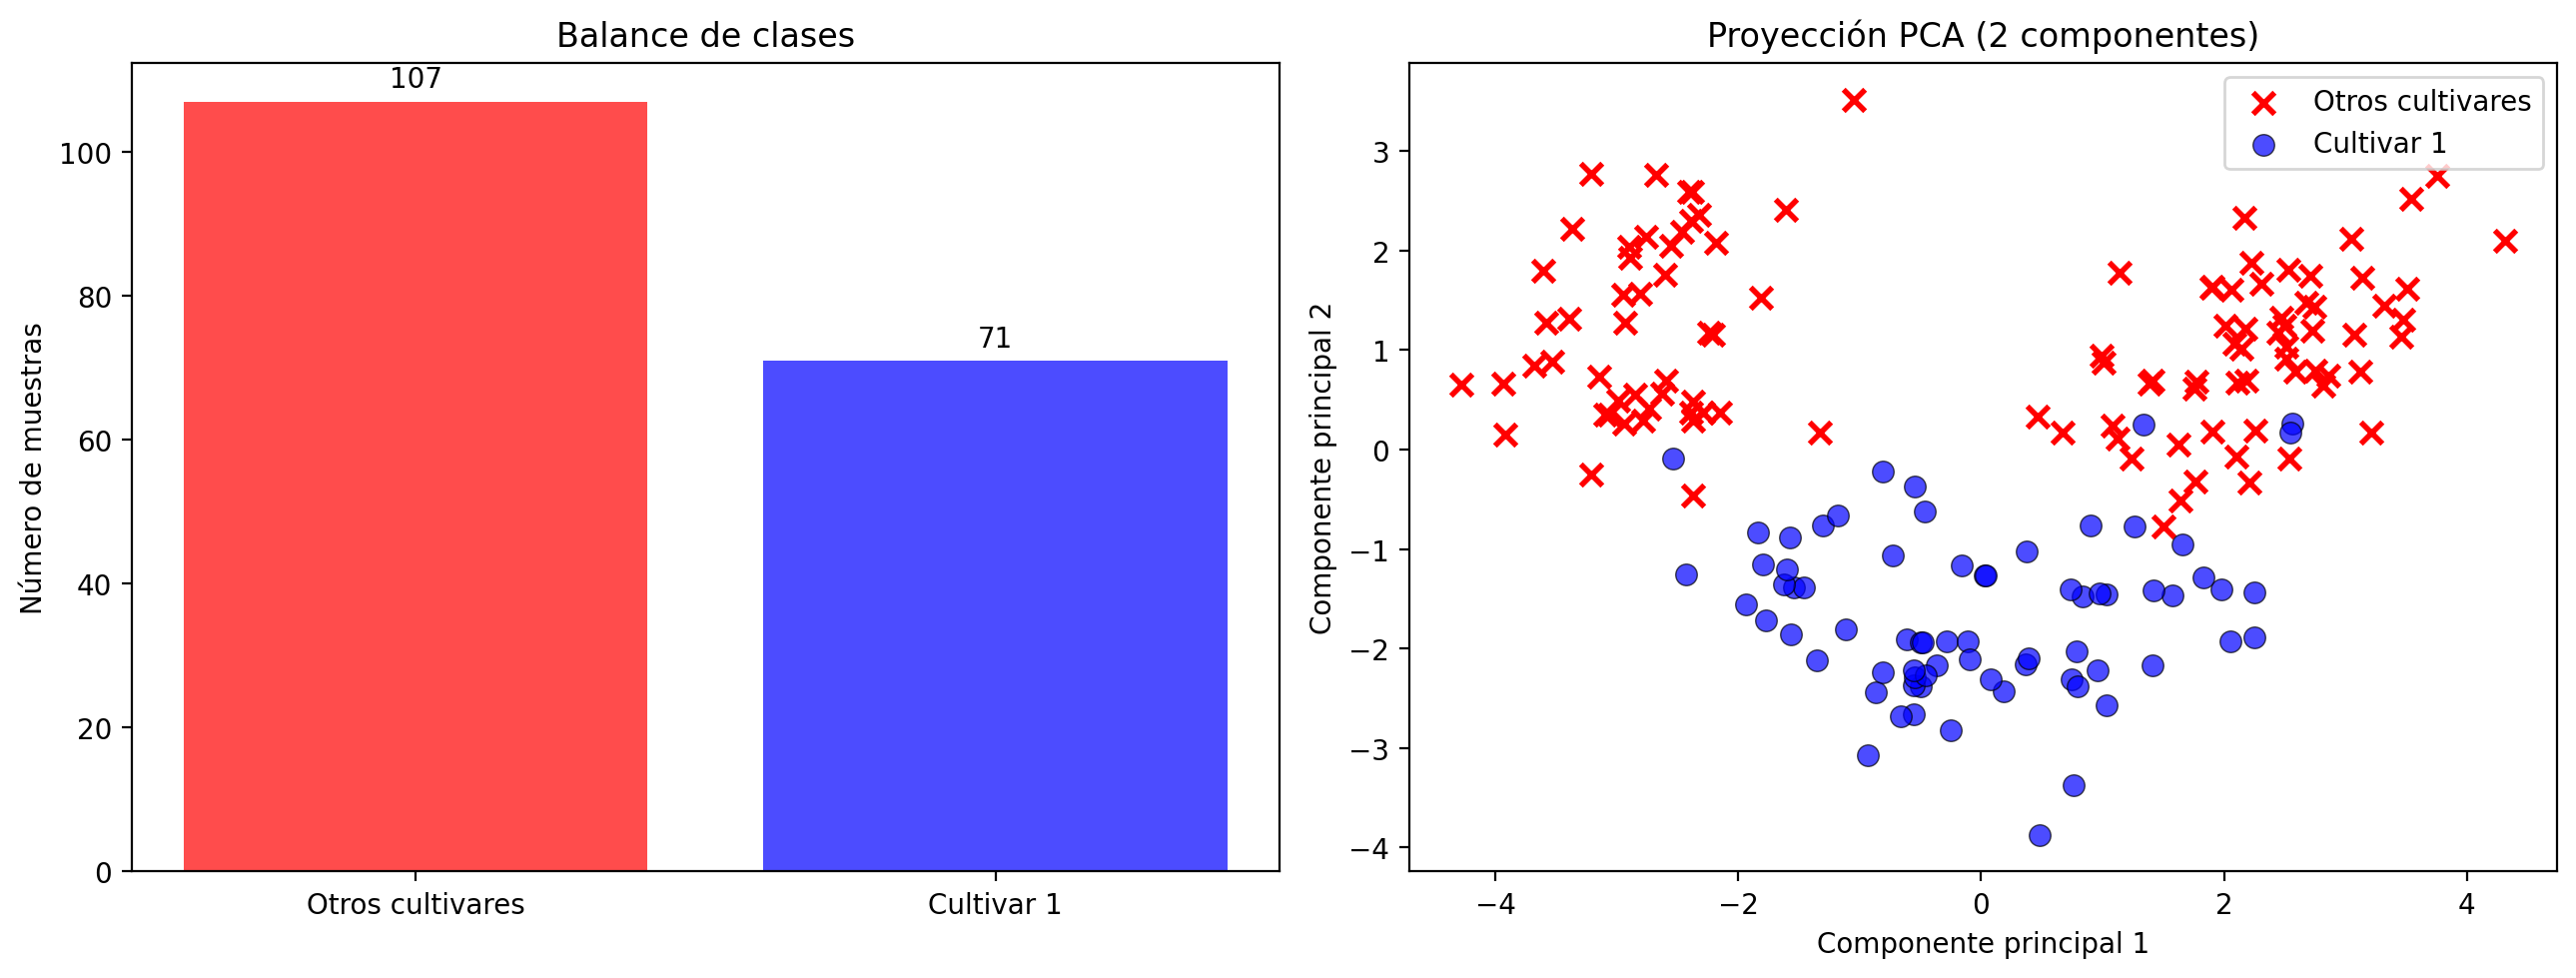

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=200)

conteos = pd.Series(y).map({0: "Otros cultivares", 1: "Cultivar 1"}).value_counts()
axes[0].bar(conteos.index, conteos.values, color=["red", "blue"], alpha=0.7)
axes[0].set_title("Balance de clases")
axes[0].set_ylabel("Número de muestras")
for i, v in enumerate(conteos.values):
    axes[0].text(i, v + 2, str(v), ha="center")

X_scaled_view = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=2, random_state=26).fit_transform(X_scaled_view)

axes[1].scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], marker="x", s=60, color="red", linewidths=2, label="Otros cultivares")
axes[1].scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], marker="o", s=60, color="blue", linewidths=0.5,
                 edgecolors="black", alpha=0.7, label="Cultivar 1")
axes[1].set_title("Proyección PCA (2 componentes)")
axes[1].set_xlabel("Componente principal 1")
axes[1].set_ylabel("Componente principal 2")
axes[1].legend()

plt.tight_layout()
plt.show()

# Análisis de las máquinas de aprendizaje supervisado

## ¿Por qué necesitamos validar un modelo?

Cuando un modelo se evalúa sobre los **mismos datos** con los que fue entrenado, la métrica resultante tiende a ser optimista: el modelo puede haber memorizado detalles particulares del conjunto de entrenamiento (sobreajuste, *overfitting*) en lugar de aprender un patrón que generalice a datos nuevos. Por eso se reserva parte de los datos para *probar* el modelo con ejemplos que no vio durante el entrenamiento.

Un simple `train_test_split` (usado en la Parte I) tiene una limitación: el resultado depende de **qué muestras** cayeron por azar en el conjunto de prueba. Con un split distinto, la misma métrica podría variar solo por la composición aleatoria de esa partición. La **validación cruzada** (*cross-validation*) resuelve esto repitiendo el proceso de entrenar/probar varias veces, con particiones distintas, y agregando los resultados — de forma que la estimación final del desempeño no depende de una sola partición afortunada (o desafortunada).

## ¿Qué es K-Fold Cross-Validation?

**K-Folds** divide el dataset completo en $k$ particiones (*folds*) de tamaño aproximadamente igual, sin solaparse entre sí. Se realizan $k$ iteraciones. En la iteración $i$:

1. Se aparta el fold $i$ completo como conjunto de prueba.
2. Se entrena el modelo con los $k-1$ folds restantes (todas las muestras excepto las del fold $i$).
3. Se predicen las etiquetas de las muestras del fold $i$ con el modelo recién entrenado.

Al terminar las $k$ iteraciones, **cada muestra del dataset fue predicha exactamente una vez** (porque cada muestra pertenece a un único fold), por un modelo que nunca la vio durante el entrenamiento. Igual que en LOOCV, con esas predicciones se construye una única matriz de confusión agregada.

Formalmente, si el dataset se particiona en $k$ folds $F_1, \dots, F_k$ y $f_{-i}$ denota el modelo entrenado con todos los folds excepto $F_i$:

$$\hat{y}_j = f_{-i}(x_j) \quad \text{para toda muestra } j \in F_i, \qquad i = 1, \dots, k$$

**Relación con LOOCV:** LOOCV (Práctica 3.1, [enlace](https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/6%20-%20Aprendizaje%20inteligente/Practica%203/3.1.%20An%C3%A1lisis%2C%20implementaci%C3%B3n%20y%20prueba%20de%20m%C3%A1quinas%20de%20aprendizaje%20supervisado%20(Parte%20II).ipynb)) es el caso particular de K-Folds donde $k = n$ (cada fold contiene una única muestra). Con $k < n$, cada iteración de K-Folds aparta **varias muestras a la vez** en lugar de una sola.

**Elección de $k$:** valores típicos son $k=5$ o $k=10$, un balance entre dos efectos:
- $k$ pequeño (p. ej. $k=5$): cada modelo se entrena con menos datos (80% del total si $k=5$), lo que puede introducir un **sesgo** ligeramente mayor, pero cada iteración es más rápida y los $k$ modelos entrenados son más distintos entre sí.
- $k$ grande (cercano a $n$, tendiendo a LOOCV): cada modelo usa casi todos los datos disponibles (menor sesgo), pero el costo computacional crece y los modelos entrenados en cada iteración se parecen mucho entre sí (mayor varianza en la estimación agregada).

En esta práctica se usa $k=10$, un valor estándar que ofrece un buen equilibrio entre sesgo, varianza y costo computacional para un dataset de 178 muestras.

**Estratificación:** dado que las clases están desbalanceadas (107 de "otros cultivares" frente a 71 del Cultivar 1), se usa `StratifiedKFold` en lugar de `KFold` simple. `StratifiedKFold` construye los $k$ folds preservando, en cada uno, la misma proporción de clases que tiene el dataset completo — evitando que, por azar, algún fold quede con muy pocos (o ningún) ejemplo de la clase minoritaria.

## Random Forest

Random Forest es un método de **ensamble** (*ensemble*): en lugar de entrenar un único modelo, entrena **muchos árboles de decisión** y combina sus predicciones. Un solo árbol de decisión tiende a sobreajustarse (memoriza el ruido de los datos de entrenamiento), pero **el promedio (o voto) de muchos árboles distintos y poco correlacionados entre sí** reduce esa varianza sin aumentar mucho el sesgo.

Para lograr que los árboles sean distintos entre sí, Random Forest introduce **dos fuentes de aleatoriedad**:

1. **Bootstrap (*bagging*):** cada árbol se entrena con una muestra aleatoria **con reemplazo** del conjunto de entrenamiento original (del mismo tamaño $n$, pero con muestras repetidas y otras ausentes). Cada árbol ve así una versión ligeramente distinta de los datos.
2. **Selección aleatoria de características:** en cada nodo del árbol, en lugar de evaluar *todas* las características disponibles para decidir el mejor corte, solo se considera un subconjunto aleatorio de ellas (típicamente $\sqrt{p}$ de las $p$ características totales, en clasificación).

**Predicción:** para clasificar una muestra nueva, cada uno de los $T$ árboles del bosque emite su propia predicción de clase, y Random Forest devuelve la **clase más votada**:

$$\hat{y} = \text{moda}\{\, \text{árbol}_1(x),\ \text{árbol}_2(x),\ \dots,\ \text{árbol}_T(x) \,\}$$

La probabilidad de pertenecer a una clase se estima como la fracción de árboles que votaron por ella.

**Hiperparámetro relevante en esta práctica:** `n_estimators` — número de árboles en el bosque (más árboles dan predicciones más estables, a costa de más tiempo de cómputo).

## Máquina de Soporte Vectorial (SVM)

Una **Support Vector Machine** busca el **hiperplano que separa las clases con el mayor margen posible**, es decir, la frontera de decisión más alejada posible de los puntos de ambas clases. Los puntos más cercanos a esa frontera —los que "sostienen" el margen— se llaman **vectores de soporte**, y son los únicos que determinan la posición del hiperplano.

Para un caso linealmente separable, la frontera de decisión es un hiperplano $w \cdot x + b = 0$, y el entrenamiento consiste en maximizar el margen $\frac{2}{\|w\|}$ sujeto a que cada punto quede correctamente clasificado fuera del margen:

$$\min_{w,b} \tfrac{1}{2}\|w\|^2 \quad \text{sujeto a} \quad y_i(w \cdot x_i + b) \geq 1 \ \ \forall i$$

En la práctica los datos casi nunca son perfectamente separables, por lo que se introduce una penalización `C` que permite que algunos puntos violen el margen: valores grandes de `C` penalizan más los errores (margen más estrecho, más ajustado a los datos); valores pequeños toleran más errores a cambio de un margen más amplio (más generalización).

**El truco del kernel (*kernel trick*):** cuando las clases no son separables por una línea recta en el espacio original, SVM puede proyectar implícitamente los datos a un espacio de mayor dimensión donde sí lo sean, sin calcular esa proyección explícitamente — solo calculando productos internos (kernels) entre pares de puntos. Aquí se usa el **kernel RBF (base radial)**:

$$K(x_i, x_j) = \exp\left(-\gamma \, \|x_i - x_j\|^2\right)$$

donde `gamma` controla qué tan "localizada" es la influencia de cada punto de entrenamiento: valores grandes hacen que cada punto influya solo en su vecindad inmediata (fronteras muy flexibles, riesgo de sobreajuste); valores pequeños extienden esa influencia más lejos (fronteras más suaves).

**Hiperparámetros relevantes en esta práctica:** `C=1.0` y `kernel="rbf"` con el `gamma` por defecto de scikit-learn (`"scale"`).

## Red Neuronal (Perceptrón Multicapa)

El **perceptrón simple** de Frank Rosenblatt es una única neurona que combina linealmente sus entradas ($z = w \cdot x + b$) y aplica una función escalón para decidir la clase. Su gran limitación es que **solo puede separar clases linealmente separables**.

El **Perceptrón Multicapa** (*Multi-Layer Perceptron*, MLP) supera esa limitación apilando varias capas de neuronas:

- Una **capa de entrada**, con una neurona por característica del dataset.
- Una o más **capas ocultas**, donde cada neurona calcula una combinación lineal de las salidas de la capa anterior y le aplica una **función de activación no lineal** (típicamente ReLU: $\text{ReLU}(z) = \max(0, z)$). Esta no linealidad es lo que permite a la red aprender fronteras de decisión curvas y complejas, no solo líneas rectas.
- Una **capa de salida**, que en clasificación binaria produce, mediante una función sigmoide, una probabilidad entre 0 y 1 de pertenecer a la clase positiva.

**Entrenamiento (backpropagation):** a diferencia del perceptrón simple (que se actualiza con la regla de Rosenblatt), el MLP se entrena minimizando una función de pérdida (entropía cruzada) mediante **descenso de gradiente**. El algoritmo de **retropropagación** (*backpropagation*) calcula, capa por capa desde la salida hacia la entrada, cuánto contribuyó cada peso al error final (aplicando la regla de la cadena del cálculo diferencial) y ajusta todos los pesos de la red en la dirección que reduce ese error.

**Hiperparámetros relevantes en esta práctica:**
- `hidden_layer_sizes=(20,)` — una sola capa oculta de 20 neuronas.
- `max_iter=500` — número máximo de épocas de entrenamiento permitidas.
- `solver="adam"` (por defecto) — variante de descenso de gradiente con tasa de aprendizaje adaptativa, adecuada para datasets pequeños/medianos.

# Implementación

Random Forest, SVM y el Perceptrón Multicapa son algoritmos considerablemente más complejos que KNN, Naive Bayes o el perceptrón simple (implementados "desde cero" en las prácticas anteriores): un bosque de cientos de árboles, la optimización cuadrática de una SVM o el descenso de gradiente con retropropagación de una red neuronal son, en la práctica, siempre delegados a bibliotecas probadas y optimizadas. Por eso aquí se utilizan las implementaciones de **scikit-learn** (`RandomForestClassifier`, `SVC`, `MLPClassifier`) para los tres algoritmos predictivos, con hiperparámetros fijos razonables (sin una búsqueda exhaustiva, que queda fuera del alcance de esta práctica).

Lo que **sí se implementa explícitamente** es el mecanismo de **K-Folds**: el ciclo que particiona el dataset en $k$ folds, y en cada iteración aparta un fold, entrena con el resto, y guarda las predicciones sobre el fold apartado.

## Demostración manual del ciclo K-Folds

Para que el mecanismo quede completamente claro, primero se implementa el ciclo **a mano**, con un bucle explícito sobre `StratifiedKFold`, usando $k=3$ sobre un subconjunto pequeño y balanceado (9 muestras de "Otros cultivares" + 9 del "Cultivar 1") para poder observar, iteración por iteración, qué fold se aparta, cuántas muestras contiene, y cuáles fueron las predicciones resultantes.

In [12]:
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC

# Subconjunto pequeño y balanceado (9 de "Otros cultivares" + 9 de "Cultivar 1") para que cada fold
# de StratifiedKFold conserve ambas clases en su interior.
idx_demo = np.concatenate([np.where(y == 0)[0][:9], np.where(y == 1)[0][:9]])
X_demo, y_demo = X[idx_demo], y[idx_demo]
skf_demo = StratifiedKFold(n_splits=3, shuffle=True, random_state=26)

for i, (train_idx, test_idx) in enumerate(skf_demo.split(X_demo, y_demo)):
    scaler = StandardScaler().fit(X_demo[train_idx])
    X_train_i = scaler.transform(X_demo[train_idx])
    X_test_i = scaler.transform(X_demo[test_idx])

    modelo = SVC(kernel="rbf", C=1.0, random_state=26).fit(X_train_i, y_demo[train_idx])
    pred = modelo.predict(X_test_i)

    print(f"Fold {i}: {len(test_idx)} muestras de prueba (índices {test_idx.tolist()})")
    print(f"  Entrenado con {len(train_idx)} muestras")
    print(f"  Etiquetas reales: {y_demo[test_idx]}")
    print(f"  Predicciones:     {pred}")
    print()

Fold 0: 6 muestras de prueba (índices [3, 4, 5, 13, 15, 17])
  Entrenado con 12 muestras
  Etiquetas reales: [0 0 0 1 1 1]
  Predicciones:     [0 0 0 1 1 1]

Fold 1: 6 muestras de prueba (índices [0, 2, 8, 12, 14, 16])
  Entrenado con 12 muestras
  Etiquetas reales: [0 0 0 1 1 1]
  Predicciones:     [0 0 0 1 1 1]

Fold 2: 6 muestras de prueba (índices [1, 6, 7, 9, 10, 11])
  Entrenado con 12 muestras
  Etiquetas reales: [0 0 0 1 1 1]
  Predicciones:     [0 0 0 1 1 1]



## Ejecución completa de K-Folds sobre las 178 muestras

Se repite el mismo procedimiento con $k=10$ sobre el dataset completo, usando `cross_val_predict(modelo, X, y, cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=26), n_jobs=-1)`. A diferencia de LOOCV —que exige 178 entrenamientos por modelo (Práctica 3.1, [enlace](https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/6%20-%20Aprendizaje%20inteligente/Practica%203/3.1.%20An%C3%A1lisis%2C%20implementaci%C3%B3n%20y%20prueba%20de%20m%C3%A1quinas%20de%20aprendizaje%20supervisado%20(Parte%20II).ipynb))—, K-Folds con $k=10$ solo exige **10 entrenamientos por modelo** (casi 18 veces menos), lo que se traduce en una ejecución prácticamente instantánea incluso sin paralelizar.

In [13]:
import time
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

def construir_modelos():
    return {
        "Random Forest": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RandomForestClassifier(n_estimators=100, random_state=26)),
        ]),
        "SVM": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="rbf", C=1.0, probability=True, random_state=26)),
        ]),
        "Red Neuronal (MLP)": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(hidden_layer_sizes=(20,), max_iter=500, random_state=26)),
        ]),
    }

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=26)
predicciones = {}
for nombre, pipeline in construir_modelos().items():
    t0 = time.time()
    predicciones[nombre] = cross_val_predict(pipeline, X, y, cv=skf, n_jobs=-1)
    print(f"{nombre}: K-Folds (k=10) completado en {time.time() - t0:.1f} s (10 entrenamientos)")

Random Forest: K-Folds (k=10) completado en 19.7 s (10 entrenamientos)
SVM: K-Folds (k=10) completado en 4.6 s (10 entrenamientos)
Red Neuronal (MLP): K-Folds (k=10) completado en 0.3 s (10 entrenamientos)


# Evaluación de las máquinas de aprendizaje supervisado

## Métricas de evaluación

A partir de las predicciones "fuera de muestra" de cada modelo (una por cada una de las 178 muestras, generada siempre por un modelo que no la vio durante el entrenamiento) se construye una **matriz de confusión agregada**. Se define **Cultivar 1** como la clase **positiva** (frente a "Otros cultivares" como clase negativa), siguiendo la binarización uno-contra-el-resto definida al cargar el dataset:

- **VP (Verdaderos Positivos):** vinos del Cultivar 1 correctamente identificados como tales.
- **VN (Verdaderos Negativos):** vinos de otros cultivares correctamente identificados como tales.
- **FP (Falsos Positivos):** vinos de otros cultivares incorrectamente clasificados como Cultivar 1.
- **FN (Falsos Negativos):** vinos del Cultivar 1 incorrectamente clasificados como de otro cultivar.

Con $N = VP+VN+FP+FN$:

| Métrica | Fórmula | Interpretación |
|---|---|---|
| Precisión Global | $\frac{VP+VN}{N}$ | Proporción total de aciertos (exactitud) |
| Error Global | $\frac{FP+FN}{N}$ | Proporción total de errores ($=1-$ Precisión Global) |
| Precisión Positiva (PP) | $\frac{VP}{VP+FN}$ | De los vinos realmente del Cultivar 1, ¿qué fracción detectó el modelo? (sensibilidad) |
| Precisión Negativa (PN) | $\frac{VN}{VN+FP}$ | De los vinos de otros cultivares, ¿qué fracción identificó correctamente? (especificidad) |
| Falsos Positivos (tasa) | $\frac{FP}{FP+VN}$ | De los vinos de otros cultivares, ¿qué fracción se clasificó erróneamente como Cultivar 1? |
| Falsos Negativos (tasa) | $\frac{FN}{FN+VP}$ | De los vinos del Cultivar 1, ¿qué fracción se clasificó erróneamente como de otro cultivar? |
| Asertividad Positiva (AP) | $\frac{VP}{VP+FP}$ | De los casos marcados como Cultivar 1, ¿qué fracción realmente lo era? (precisión) |
| Asertividad Negativa (NP) | $\frac{VN}{VN+FN}$ | De los casos marcados como otros cultivares, ¿qué fracción realmente lo era? (valor predictivo negativo) |

In [14]:
def calcular_metricas(y_true, y_pred, clase_positiva=1):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    VP = np.sum((y_true == clase_positiva) & (y_pred == clase_positiva))
    VN = np.sum((y_true != clase_positiva) & (y_pred != clase_positiva))
    FP = np.sum((y_true != clase_positiva) & (y_pred == clase_positiva))
    FN = np.sum((y_true == clase_positiva) & (y_pred != clase_positiva))
    N = VP + VN + FP + FN

    return {
        "VP": VP, "VN": VN, "FP": FP, "FN": FN,
        "Precisión Global": (VP + VN) / N,
        "Error Global": (FP + FN) / N,
        "PP": VP / (VP + FN),
        "PN": VN / (VN + FP),
        "Tasa FP": FP / (FP + VN),
        "Tasa FN": FN / (FN + VP),
        "AP": VP / (VP + FP),
        "NP": VN / (VN + FN),
    }


tabla_metricas = pd.DataFrame({
    nombre: calcular_metricas(y, pred) for nombre, pred in predicciones.items()
}).T
tabla_metricas[["VP", "VN", "FP", "FN"]] = tabla_metricas[["VP", "VN", "FP", "FN"]].astype(int)
tabla_metricas.round(4)

,VP,VN,FP,FN,Precisión Global,Error Global,PP,PN,Tasa FP,Tasa FN,AP,NP
Random Forest,68,107,0,3,0.9831,0.0169,0.9577,1.0000,0.0000,0.0423,1.0000,0.9727
SVM,70,107,0,1,0.9944,0.0056,0.9859,1.0000,0.0000,0.0141,1.0000,0.9907
Red Neuronal (MLP),70,106,1,1,0.9888,0.0112,0.9859,0.9907,0.0093,0.0141,0.9859,0.9907


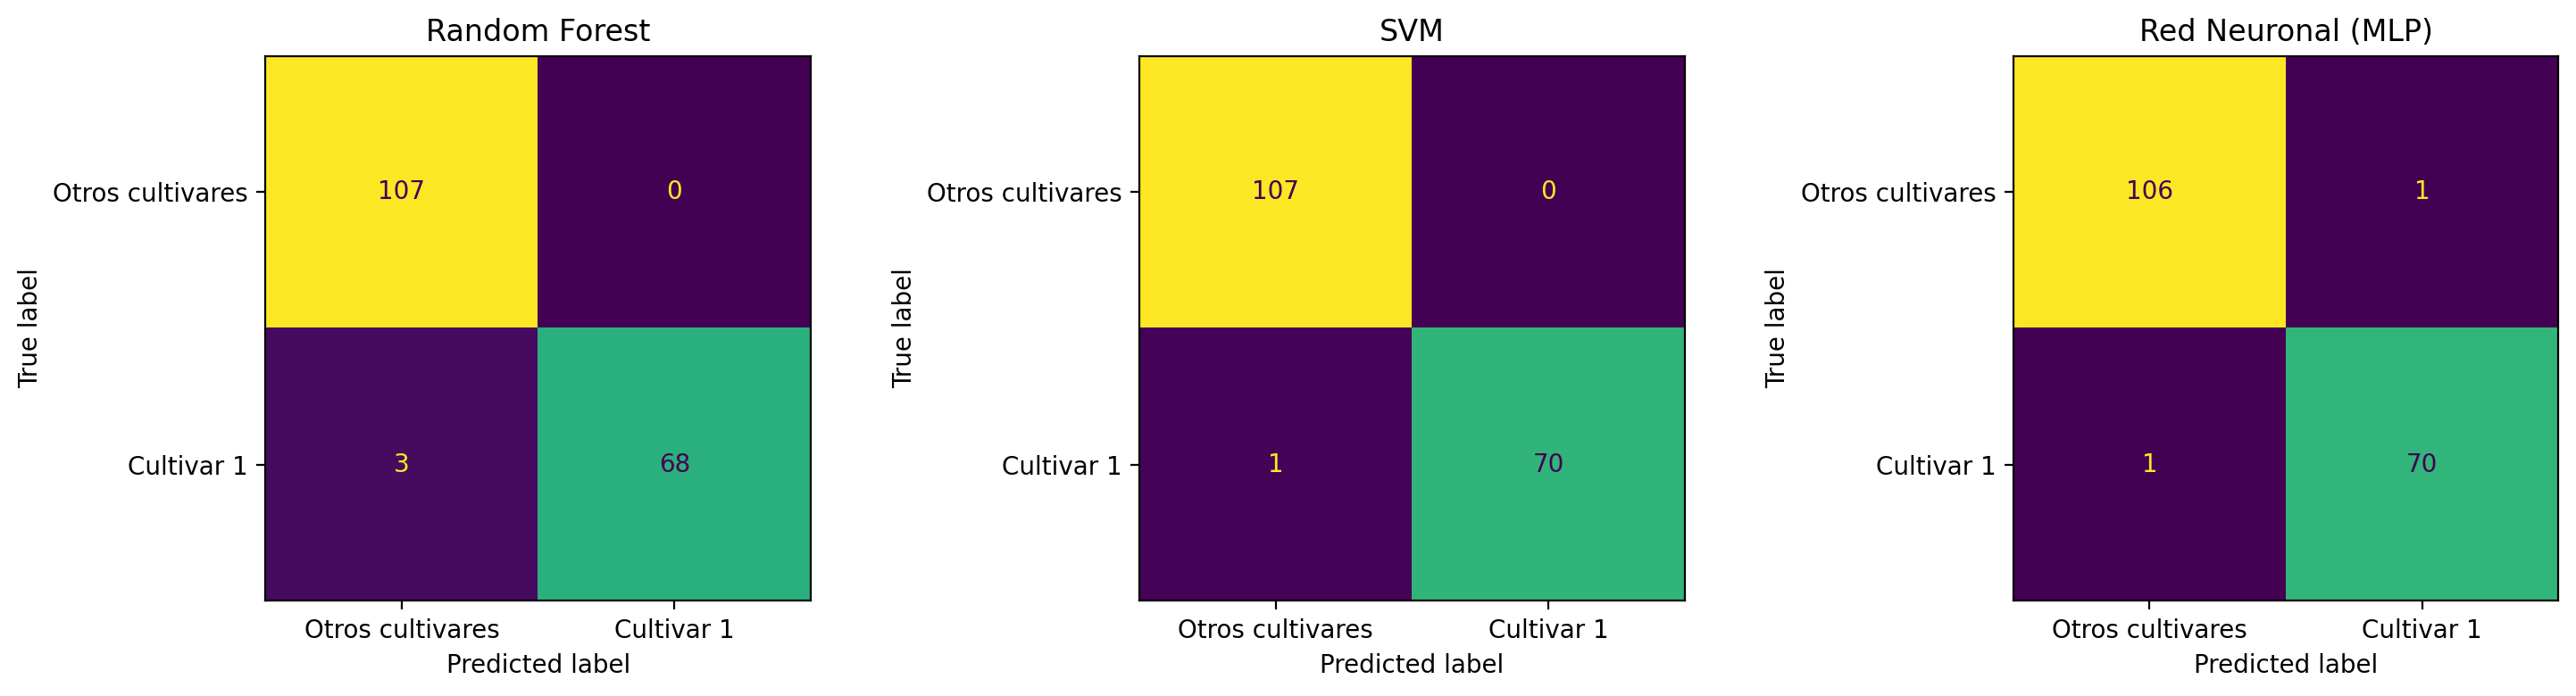

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, len(predicciones), figsize=(5 * len(predicciones), 4), dpi=200)
for ax, (nombre, pred) in zip(axes, predicciones.items()):
    ConfusionMatrixDisplay.from_predictions(
        y, pred, display_labels=["Otros cultivares", "Cultivar 1"], ax=ax, colorbar=False
    )
    ax.set_title(nombre)
plt.tight_layout()
plt.show()

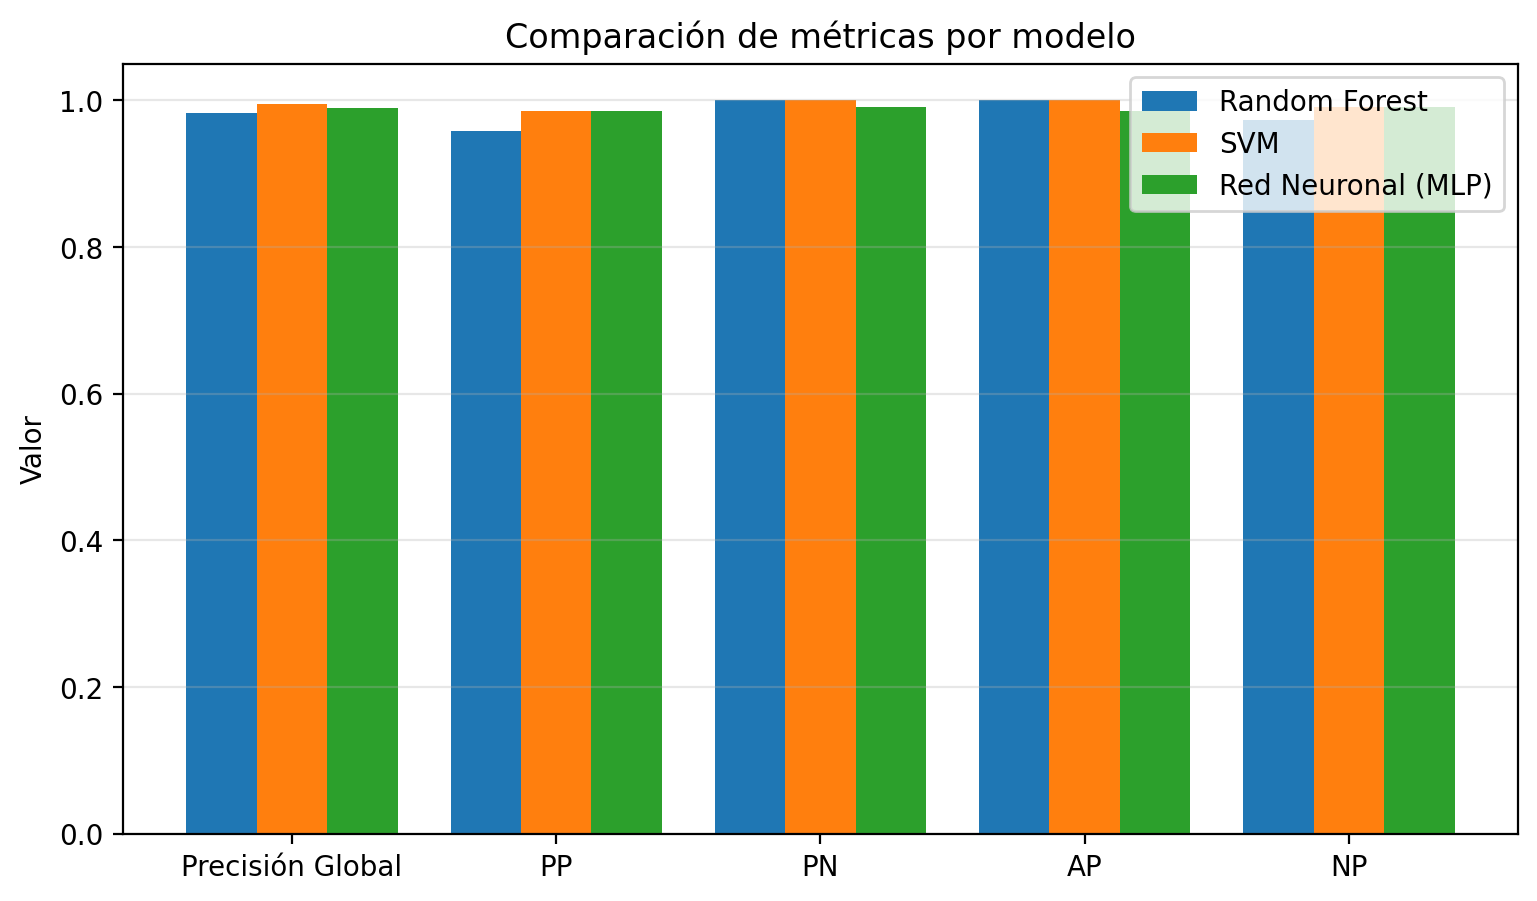

In [16]:
metricas_plot = ["Precisión Global", "PP", "PN", "AP", "NP"]
x = np.arange(len(metricas_plot))
ancho = 0.8 / len(predicciones)

plt.figure(figsize=(9, 5), dpi=200)
for i, nombre in enumerate(predicciones):
    valores = tabla_metricas.loc[nombre, metricas_plot].values.astype(float)
    plt.bar(x + i * ancho, valores, width=ancho, label=nombre)

plt.xticks(x + ancho * (len(predicciones) - 1) / 2, metricas_plot)
plt.ylim(0, 1.05)
plt.ylabel("Valor")
plt.title("Comparación de métricas por modelo")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

## Análisis comparativo

Con las 178 predicciones de K-Folds ($k=10$, una por muestra), los resultados fueron:

| Modelo | Precisión Global | Error Global | PP | PN | Tasa FP | Tasa FN | AP | NP |
|---|---|---|---|---|---|---|---|---|
| Random Forest | 0.9831 | 0.0169 | 0.9577 | 1.0000 | 0.0000 | 0.0423 | 1.0000 | 0.9727 |
| SVM | 0.9944 | 0.0056 | 0.9859 | 1.0000 | 0.0000 | 0.0141 | 1.0000 | 0.9907 |
| Red Neuronal (MLP) | 0.9888 | 0.0112 | 0.9859 | 0.9907 | 0.0093 | 0.0141 | 0.9859 | 0.9907 |

**Lectura de resultados:** aquí sí hay un modelo que domina: **SVM** obtuvo la mejor Precisión Global (0.9944) y el menor Error Global (0.0056), con un único error en las 178 muestras (1 Falso Negativo, 0 Falsos Positivos: AP = 1.0000 y PN = 1.0000). Random Forest volvió a cometer 3 errores, siempre del mismo tipo (Falsos Negativos, nunca Falsos Positivos), igual que bajo LOOCV. La Red Neuronal quedó en un punto intermedio, con 1 Falso Positivo y 1 Falso Negativo.

**Comparación LOOCV vs. K-Folds sobre el mismo dataset:**

| Modelo | Precisión Global (LOOCV) | Precisión Global (K-Folds, k=10) | Diferencia |
|---|---|---|---|
| Random Forest | 0.9831 | 0.9831 | 0.0000 |
| SVM | 0.9831 | 0.9944 | +0.0113 |
| Red Neuronal (MLP) | 0.9831 | 0.9888 | +0.0057 |

Random Forest obtuvo **exactamente el mismo resultado** con ambas técnicas (mismos VP/VN/FP/FN), lo cual sugiere que sus errores en este dataset no dependen de qué muestras específicas se usan para entrenar en cada iteración. SVM y la Red Neuronal, en cambio, mejoraron con K-Folds respecto a LOOCV — probablemente porque en K-Folds cada modelo se entrena con folds de 160-161 muestras (barajadas con `shuffle=True`) en lugar de con 177 muestras casi idénticas entre iteraciones, lo que puede producir fronteras de decisión ligeramente distintas. En cualquier caso, las diferencias son pequeñas (máximo 1.13 puntos porcentuales), consistente con que ambas técnicas evalúan, en última instancia, la misma cantidad de predicciones fuera de muestra (178) sobre el mismo dataset.

# Conclusiones

Implementar el ciclo de **K-Folds** explícitamente —primero a mano con $k=3$ sobre un subconjunto pequeño usando `StratifiedKFold`, y después a escala completa con $k=10$ sobre las 178 muestras usando `cross_val_predict`— permitió comprobar su definición: el dataset se particiona en $k$ folds disjuntos que preservan la proporción de clases, y cada muestra es predicha exactamente una vez por un modelo que se entrenó sin ella.

Sobre el dataset Wine recognition (binarizado a Cultivar 1 vs. Otros cultivares), **los tres modelos alcanzaron un desempeño alto** (Precisión Global entre 0.9831 y 0.9944), con **SVM como el mejor modelo** (un único error en 178 muestras), seguido de la Red Neuronal y, en tercer lugar, Random Forest — a diferencia de la Práctica 3.1 ([enlace](https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/6%20-%20Aprendizaje%20inteligente/Practica%203/3.1.%20An%C3%A1lisis%2C%20implementaci%C3%B3n%20y%20prueba%20de%20m%C3%A1quinas%20de%20aprendizaje%20supervisado%20(Parte%20II).ipynb)), donde los tres modelos habían empatado en Precisión Global bajo LOOCV.

La comparación directa entre ambas técnicas de validación sobre el mismo dataset mostró que **LOOCV y K-Folds ($k=10$) producen estimaciones de desempeño muy similares pero no idénticas**: Random Forest coincidió exactamente entre ambas técnicas, mientras que SVM y la Red Neuronal mejoraron ligeramente con K-Folds (diferencias de hasta 1.13 puntos porcentuales de Precisión Global). El costo computacional, en cambio, sí fue muy distinto: K-Folds necesitó 10 entrenamientos por modelo frente a los 178 de LOOCV, casi 18 veces menos. Esto ilustra el principio central detrás de la elección de una técnica de validación cruzada: **cuando el dataset es lo suficientemente grande y las clases están razonablemente representadas en cada partición, K-Folds con un $k$ moderado (5 o 10) ofrece una estimación tan confiable como LOOCV a una fracción de su costo computacional** — por lo que, en la práctica, K-Folds suele preferirse sobre LOOCV salvo en datasets muy pequeños, donde maximizar los datos de entrenamiento en cada iteración (la ventaja principal de LOOCV) pesa más que el ahorro computacional.

## Referencias

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning with Applications in R* (2nd ed.). Springer. [https://doi.org/10.1007/978-1-0716-1418-1](https://doi.org/10.1007/978-1-0716-1418-1)

Scikit-learn developers. (s.f.). *sklearn.model_selection.StratifiedKFold*. Scikit-learn 1.7 documentation. [https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html)

Hernández Parada, M. S. (2026). *3.1. Análisis, implementación y prueba de máquinas de aprendizaje supervisado (Parte II)* [Jupyter notebook]. GitHub. [https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/6%20-%20Aprendizaje%20inteligente/Practica%203/3.1.%20An%C3%A1lisis%2C%20implementaci%C3%B3n%20y%20prueba%20de%20m%C3%A1quinas%20de%20aprendizaje%20supervisado%20(Parte%20II).ipynb](https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/6%20-%20Aprendizaje%20inteligente/Practica%203/3.1.%20An%C3%A1lisis%2C%20implementaci%C3%B3n%20y%20prueba%20de%20m%C3%A1quinas%20de%20aprendizaje%20supervisado%20(Parte%20II).ipynb)

Aeberhard, S., Coomans, D., & de Vel, O. (1992). *Wine* [Dataset]. UCI Machine Learning Repository. [https://doi.org/10.24432/C5PC7J](https://doi.org/10.24432/C5PC7J)

Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32. [https://doi.org/10.1023/A:1010933404324](https://doi.org/10.1023/A:1010933404324)

Cortes, C., & Vapnik, V. (1995). Support-vector networks. *Machine Learning*, 20(3), 273–297. [https://doi.org/10.1007/BF00994018](https://doi.org/10.1007/BF00994018)

Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). Learning representations by back-propagating errors. *Nature*, 323(6088), 533–536. [https://doi.org/10.1038/323533a0](https://doi.org/10.1038/323533a0)

Hernández Orallo, J., Ramírez Quintana, M. J., & Ferri Ramírez, C. (2004). *Introducción a la minería de datos*. Pearson Educación.

Scikit-learn developers. (s.f.). *sklearn.ensemble.RandomForestClassifier*. Scikit-learn 1.7 documentation. [https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

Scikit-learn developers. (s.f.). *sklearn.svm.SVC*. Scikit-learn 1.7 documentation. [https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)

Scikit-learn developers. (s.f.). *sklearn.neural_network.MLPClassifier*. Scikit-learn 1.7 documentation. [https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)

Hernández Parada, M. S. (2026). *Maestría en Inteligencia Artificial — Prácticas* [Repositorio de GitHub]. GitHub. [https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/6%20-%20Aprendizaje%20inteligente/Practica%203/3.2.%20An%C3%A1lisis%2C%20implementaci%C3%B3n%20y%20prueba%20de%20m%C3%A1quinas%20de%20aprendizaje%20supervisado%20(Parte%20II).ipynb](https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/6%20-%20Aprendizaje%20inteligente/Practica%203/3.2.%20An%C3%A1lisis%2C%20implementaci%C3%B3n%20y%20prueba%20de%20m%C3%A1quinas%20de%20aprendizaje%20supervisado%20(Parte%20II).ipynb)